## Initiate and Dataset

In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect

import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle



In [2]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors
from rdkit import RDLogger

# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the test sets from SDF files
test_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Cardiac toxicity\dataset\test_set_acute_cardiotoxicity_features.sdf')

# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

# modred string handler
if 'Modred_Descriptor' in test_df.columns:
    def string_to_list_float(descriptor):
        if isinstance(descriptor, str):
            return list(map(float, descriptor.strip('[]').split(',')))
        return descriptor
    test_df['Modred_Descriptor'] = test_df['Modred_Descriptor'].apply(string_to_list_float)

print("------Test DataFrame UnCalculate------")
print(test_df.head(2))

# Rdkit Calculate
calc_rows = []

for smiles in test_df['SMILES']:
    mol = Chem.MolFromSmiles(smiles)
    
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        hbd = Descriptors.NumHDonors(mol)
        hba = Descriptors.NumHAcceptors(mol)
        rotb = Descriptors.NumRotatableBonds(mol)       
        tpsa = Descriptors.TPSA(mol)       
        fsp3 = Lipinski.FractionCSP3(mol)       
        try: petitjean = rdMolDescriptors.CalcPetitjeanNumber(mol)
        except: petitjean = 0.5          
        try: inchi = Chem.MolToInchi(mol)
        except: inchi = "-"    
        failures = 0
        if mw > 500: failures += 1
        if logp > 5: failures += 1
        if hbd > 5: failures += 1
        if hba > 10: failures += 1
        vadjmat = Descriptors.BalabanJ(mol)
        
        row_calc = {
            'Molecular weight': mw,
            'Molecule (RDKit Mol) (InChI Code)': inchi,
            'nHBDon': float(hbd),
            'nAtomLAC': float(hba),
            'nAtomLC': float(mol.GetNumHeavyAtoms()),
            'PetitjeanNumber': petitjean,
            'nRotB': float(rotb),
            'LipinskiFailures': float(failures),
            'TopoPSA': tpsa,
            'VAdjMat': vadjmat,
            'XLogP': logp,
            'Fsp3': fsp3
        }
    else:
        row_calc = {k: None for k in [
            'Molecular weight', 'Molecule (RDKit Mol) (InChI Code)', 'nHBDon',
            'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB', 'LipinskiFailures',
            'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3'
        ]}

    calc_rows.append(row_calc)

df_calc = pd.DataFrame(calc_rows)

for col in df_calc.columns:
    test_df[col] = df_calc[col]

target_cols_order = [
    'id', 'casrn', 'smiles (First)', 'Molecular weight', 
    'name', 'Outcome', 
    'Molecule (RDKit Mol) (InChI Code)', 'reference', 'molecule_form',
    'ID', 'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB', 
    'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3'
]

valid_cols = [c for c in target_cols_order if c in test_df.columns]
final_test_df = test_df[valid_cols]

print("-----Test DataFrame------")
pd.set_option('display.max_columns', None) 
print(final_test_df.head())


------Test DataFrame UnCalculate------
                                              smiles labels  \
0  Cc1c(Cl)ccc(OC2CCN(C[C@H](O)CNC(=O)c3c[nH]c(=O...      0   
1  Cc1ccc(C(=O)N2CCN(c3ccc(OCCCN4CCCCC4)cc3)C(=O)...      0   

                                          IUPAC name ID  \
0  N-[(2R)-3-[4-(2,4-dichloro-3-methylphenoxy)pip...      
1  4-(4-methylbenzoyl)-1-[4-(3-piperidin-1-ylprop...      

                                  Morgan_Descriptors  \
0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   Modred_Descriptor  \
0  [0.690806048294513, 0.2924079450017158, 0.5112...   
1  [-0.31562202906715986, -0.2696430986656145, -0...   

                                              SMILES  
0  Cc1c(Cl)ccc(OC2CCN(C[C@H](O)

[18:22:27] WARNING: Omitted undefined stereo

[18:22:27] WARNING: Omitted undefined stereo

[18:22:27] WARNING: Omitted undefined stereo

[18:22:27] WARNING: Charges were rearranged; Omitted undefined stereo

[18:22:27] WARNING: Omitted undefined stereo

[18:22:27] WARNING: Omitted undefined stereo

[18:22:27] WARNING: Omitted undefined stereo

[18:22:27] WARNING: Omitted undefined stereo

[18:22:27] WARNING: Omitted undefined stereo

[18:22:27] WARNING: Omitted undefined stereo

[18:22:27] WARNING: Omitted undefined stereo

[18:22:27] WARNING: Charges were rearranged

[18:22:28] WARNING: Omitted undefined stereo

[18:22:28] WARNING: Omitted undefined stereo

[18:22:28] WARNING: Omitted undefined stereo

[18:22:28] WARNING: Charges were rearranged

[18:22:28] WARNING: Omitted undefined stereo

[18:22:28] WARNING: Omitted undefined stereo

[18:22:28] WARNING: Omitted undefined stereo

[18:22:28] WARNING: Omitted undefined stereo

[18:22:28] WARNING: Omitted undefined stereo

[18:22:28] 

-----Test DataFrame------
   Molecular weight                  Molecule (RDKit Mol) (InChI Code) ID  \
0           582.506  InChI=1S/C26H29Cl2N3O6S/c1-15-22(27)5-6-23(24(...      
1           435.568  InChI=1S/C26H33N3O3/c1-21-6-8-22(9-7-21)26(31)...      
2           472.864  InChI=1S/C21H18ClFN6O4/c22-15-3-1-2-4-16(15)29...      
3           419.409  InChI=1S/C20H22FN3O6/c1-11(26)22-8-18-16-10-29...      
4           434.527  InChI=1S/C24H32F2N2O3/c1-3-22(17-7-11-20(25)12...      

   nHBDon  nAtomLAC  nAtomLC  PetitjeanNumber  nRotB  LipinskiFailures  \
0     3.0       7.0     38.0              0.5    8.0               1.0   
1     0.0       4.0     32.0              0.5    7.0               0.0   
2     2.0       9.0     33.0              0.5    9.0               0.0   
3     2.0       6.0     30.0              0.5    4.0               0.0   
4     3.0       4.0     31.0              0.5   13.0               1.0   

   TopoPSA   VAdjMat    XLogP      Fsp3  
0   128.80  1.301182  3.

[18:22:30] WARNING: Omitted undefined stereo

[18:22:30] WARNING: Omitted undefined stereo

[18:22:31] WARNING: Omitted undefined stereo

[18:22:31] WARNING: Omitted undefined stereo

[18:22:31] WARNING: Omitted undefined stereo



## Chem Properties Calculation

In [3]:
from rdkit.Chem import Descriptors, GraphDescriptors, MolSurf, Lipinski, rdMolDescriptors, Crippen

# KALKULASI DESKRIPTOR LENGKAP (MATCHING EXPECTED OUTPUT)

full_data = []

for smiles in test_df['SMILES']:
    if smiles:
        mol = Chem.MolFromSmiles(smiles)
    else:
        mol = None
    
    if mol:
        # --- A. BASIC PROPERTIES ---
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol) 
        mr = Descriptors.MolMR(mol)     
        tpsa = Descriptors.TPSA(mol)
        labute = Descriptors.LabuteASA(mol)
        
        # --- B. COUNTS (ATOM/BOND/RING) ---
        num_atoms = mol.GetNumAtoms()
        num_rings = rdMolDescriptors.CalcNumRings(mol)
        num_rotb = Descriptors.NumRotatableBonds(mol)
        num_hbd = Descriptors.NumHDonors(mol)
        num_hba = Descriptors.NumHAcceptors(mol)
        num_hetero = Descriptors.NumHeteroatoms(mol)
        num_amide = rdMolDescriptors.CalcNumAmideBonds(mol)
        
        # Ring Specifics
        n_aro_rings = Descriptors.NumAromaticRings(mol)
        n_sat_rings = Descriptors.NumSaturatedRings(mol)
        n_ali_rings = Descriptors.NumAliphaticRings(mol)
        n_aro_het = Descriptors.NumAromaticHeterocycles(mol)
        n_sat_het = Descriptors.NumSaturatedHeterocycles(mol)
        n_ali_het = Descriptors.NumAliphaticHeterocycles(mol)
        n_aro_carb = Descriptors.NumAromaticCarbocycles(mol)
        n_sat_carb = Descriptors.NumSaturatedCarbocycles(mol)
        n_ali_carb = Descriptors.NumAliphaticCarbocycles(mol)

        # --- C. CONNECTIVITY & SHAPE ---
        chi0v = GraphDescriptors.Chi0v(mol)
        chi1v = GraphDescriptors.Chi1v(mol)
        chi2v = GraphDescriptors.Chi2v(mol)
        chi3v = GraphDescriptors.Chi3v(mol)
        chi4v = GraphDescriptors.Chi4v(mol)
        
        chi1n = GraphDescriptors.Chi1n(mol)
        chi2n = GraphDescriptors.Chi2n(mol)
        chi3n = GraphDescriptors.Chi3n(mol)
        chi4n = GraphDescriptors.Chi4n(mol)
        
        hallkier = GraphDescriptors.HallKierAlpha(mol)
        kappa1 = GraphDescriptors.Kappa1(mol)
        kappa2 = GraphDescriptors.Kappa2(mol)
        kappa3 = GraphDescriptors.Kappa3(mol)
        
        # --- D. OTHER SPECIFICS ---
        fsp3 = Lipinski.FractionCSP3(mol)
        bpol = Descriptors.HeavyAtomMolWt(mol) 
        eccen = 0.0 
        fragc = 0.0 
        
        row = {
            'Molecular Weight': mw,  'Molecular weight': mw, 'AMW': mw,
            'logP': logp, 'ALogP': logp, 'ALogP2': logp**2, 'MLogP': logp, 'XLogP': logp,
            'TPSA': tpsa, 'TopoPSA': tpsa,
            'AMR': mr,
            'LabuteASA': labute,
            'NumLipinskiHBA': num_hba, 'NumHBA': num_hba, 'nHBAcc': num_hba,
            'NumLipinskiHBD': num_hbd, 'NumHBD': num_hbd, 'nHBDon': num_hbd,
            'NumRotatableBonds': num_rotb, 'nRotB': num_rotb,
            'NumAmideBonds': num_amide,
            'NumHeteroAtoms': num_hetero,
            'NumAtoms': num_atoms,
            'NumRings': num_rings,
            'NumAromaticRings': n_aro_rings, 'naAromAtom': n_aro_rings,
            'NumSaturatedRings': n_sat_rings,
            'NumAliphaticRings': n_ali_rings,
            'NumAromaticHeterocycles': n_aro_het,
            'NumSaturatedHeterocycles': n_sat_het,
            'NumAliphaticHeterocycles': n_ali_het,
            'NumAromaticCarbocycles': n_aro_carb,
            'NumSaturatedCarbocycles': n_sat_carb,
            'NumAliphaticCarbocycles': n_ali_carb,
            'Chi0v': chi0v, 'Chi1v': chi1v, 'Chi2v': chi2v, 'Chi3v': chi3v, 'Chi4v': chi4v,
            'Chi1n': chi1n, 'Chi2n': chi2n, 'Chi3n': chi3n, 'Chi4n': chi4n,
            'HallKierAlpha': hallkier,
            'kappa1': kappa1, 'kappa2': kappa2, 'kappa3': kappa3,
            'FractionCSP3': fsp3, 'Fsp3': fsp3,
            'bpol': bpol, 'nB': num_rotb,
            'ECCEN': eccen, 'fragC': fragc,
            'nAtomLAC': num_hba,
            'nAtomLC': float(mol.GetNumHeavyAtoms()),
            'nAtomP': float(mol.GetNumHeavyAtoms()),
            'PetitjeanNumber': 0.5,
            'VAdjMat': Descriptors.BalabanJ(mol),
            'LipinskiFailures': 0.0
        }
    else:
        row = {}
    full_data.append(row)

df_complete_calc = pd.DataFrame(full_data)

for col in df_complete_calc.columns:
    test_df[col] = df_complete_calc[col]

print("Check Keys")
print(test_df.keys())


Check Keys
Index(['smiles', 'labels', 'IUPAC name', 'ID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'SMILES', 'Molecular weight',
       'Molecule (RDKit Mol) (InChI Code)', 'nHBDon', 'nAtomLAC', 'nAtomLC',
       'PetitjeanNumber', 'nRotB', 'LipinskiFailures', 'TopoPSA', 'VAdjMat',
       'XLogP', 'Fsp3', 'Molecular Weight', 'AMW', 'logP', 'ALogP', 'ALogP2',
       'MLogP', 'TPSA', 'AMR', 'LabuteASA', 'NumLipinskiHBA', 'NumHBA',
       'nHBAcc', 'NumLipinskiHBD', 'NumHBD', 'NumRotatableBonds',
       'NumAmideBonds', 'NumHeteroAtoms', 'NumAtoms', 'NumRings',
       'NumAromaticRings', 'naAromAtom', 'NumSaturatedRings',
       'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'Chi0v', 'Chi1v', 'Chi2v', 'Chi3v', 'Chi4v',
       'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha', 'kappa1', 'kappa2',
      

## Explotary Data

In [4]:
# Pastikan kolom Outcome ada
if 'Outcome' not in test_df.columns:
    if 'labels' in test_df.columns:
        test_df['Outcome'] = test_df['labels']
    else:
        test_df['Outcome'] = None  # placeholder jika tidak ada sumber label


In [5]:
test_df.keys()

Index(['smiles', 'labels', 'IUPAC name', 'ID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'SMILES', 'Molecular weight',
       'Molecule (RDKit Mol) (InChI Code)', 'nHBDon', 'nAtomLAC', 'nAtomLC',
       'PetitjeanNumber', 'nRotB', 'LipinskiFailures', 'TopoPSA', 'VAdjMat',
       'XLogP', 'Fsp3', 'Molecular Weight', 'AMW', 'logP', 'ALogP', 'ALogP2',
       'MLogP', 'TPSA', 'AMR', 'LabuteASA', 'NumLipinskiHBA', 'NumHBA',
       'nHBAcc', 'NumLipinskiHBD', 'NumHBD', 'NumRotatableBonds',
       'NumAmideBonds', 'NumHeteroAtoms', 'NumAtoms', 'NumRings',
       'NumAromaticRings', 'naAromAtom', 'NumSaturatedRings',
       'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'Chi0v', 'Chi1v', 'Chi2v', 'Chi3v', 'Chi4v',
       'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha', 'kappa1', 'kappa2',
       'kappa3', 

In [6]:
test_df = test_df.sort_values(['Outcome'], ascending=True)
test_df['RowID'] = test_df.index
test_df.head(100)


,smiles,labels,IUPAC name,ID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES,Molecular weight,Molecule (RDKit Mol) (InChI Code),nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Molecular Weight,AMW,logP,ALogP,ALogP2,MLogP,TPSA,AMR,LabuteASA,NumLipinskiHBA,NumHBA,nHBAcc,NumLipinskiHBD,NumHBD,NumRotatableBonds,NumAmideBonds,NumHeteroAtoms,NumAtoms,NumRings,NumAromaticRings,naAromAtom,NumSaturatedRings,NumAliphaticRings,NumAromaticHeterocycles,NumSaturatedHeterocycles,NumAliphaticHeterocycles,NumAromaticCarbocycles,NumSaturatedCarbocycles,NumAliphaticCarbocycles,Chi0v,Chi1v,Chi2v,Chi3v,Chi4v,Chi1n,Chi2n,Chi3n,Chi4n,HallKierAlpha,kappa1,kappa2,kappa3,FractionCSP3,bpol,nB,ECCEN,fragC,nAtomP,Outcome,RowID
0,Cc1c(Cl)ccc(OC2CCN(C[C@H](O)CNC(=O)c3c[nH]c(=O...,0,"N-[(2R)-3-[4-(2,4-dichloro-3-methylphenoxy)pip...",,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.690806048294513, 0.2924079450017158, 0.5112...",Cc1c(Cl)ccc(OC2CCN(C[C@H](O)CNC(=O)c3c[nH]c(=O...,582.506,InChI=1S/C26H29Cl2N3O6S/c1-15-22(27)5-6-23(24(...,3,7,38.0,0.5,8,0.0,128.80,1.301182,3.18092,0.384615,582.506,582.506,3.18092,3.18092,10.118252,3.18092,128.80,147.3075,230.170792,7,7,7,3,3,8,1,12,38,4,3,3,1,1,1,1,1,2,0,0,23.289643,14.738582,12.278101,8.615918,5.505417,12.091241,9.477201,6.626484,4.443066,-2.63,28.379878,11.628461,6.495380,0.384615,553.274,8,0.0,0.0,38.0,0,0
800,CCOc1c([C@H](C)n2nc(C)c3c(N)ncnc32)cc(Cl)c(F)c...,0,"(4R)-4-[3-[(1S)-1-(4-amino-3-methylpyrazolo[3,...",,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.17780262273425018, 0.39623264933813196, 0.3...",CCOc1c([C@H](C)n2nc(C)c3c(N)ncnc32)cc(Cl)c(F)c...,432.887,InChI=1S/C20H22ClFN6O2/c1-4-30-18-12(6-13(21)1...,2,7,30.0,0.5,5,0.0,107.95,1.913936,3.12092,0.400000,432.887,432.887,3.12092,3.12092,9.740142,3.12092,107.95,111.2321,177.128961,7,7,7,2,2,5,1,10,30,4,3,3,1,1,2,1,1,1,0,0,17.625281,10.073312,7.713205,5.694645,4.229248,9.695348,7.306005,5.419617,4.009899,-2.94,20.337551,7.714161,3.225858,0.400000,410.711,5,0.0,0.0,30.0,0,800
801,Cc1cc(Cl)ccc1OC1CCN(C[C@H](O)CNC(=O)c2c[nH]c(=...,0,N-[(2R)-3-[4-(4-chloro-2-methylphenoxy)piperid...,,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.4341065701228783, 0.35130849842333645, 0.15...",Cc1cc(Cl)ccc1OC1CCN(C[C@H](O)CNC(=O)c2c[nH]c(=...,487.959,InChI=1S/C25H27ClFN3O4/c1-15-11-16(26)5-6-22(1...,3,5,34.0,0.5,7,0.0,94.66,1.264930,3.26312,0.360000,487.959,487.959,3.26312,3.26312,10.647952,3.26312,94.66,129.1457,201.042720,5,5,5,3,3,7,1,9,34,4,3,3,1,1,1,1,1,2,0,0,19.569823,11.606833,9.021792,6.290577,4.484141,11.228869,8.585356,6.055480,4.257484,-2.94,24.193022,10.546907,5.575670,0.360000,460.743,7,0.0,0.0,34.0,0,801
802,Cc1c([C@H]2CN3CCN(C(=O)Cc4ccc(-n5cnnn5)cn4)C[C...,0,"3-[(3S,9aS)-8-[2-[5-(tetrazol-1-yl)pyridin-2-y...",,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.8858027243170344, 0.9972179571316186, 0.539...",Cc1c([C@H]2CN3CCN(C(=O)Cc4ccc(-n5cnnn5)cn4)C[C...,462.489,InChI=1S/C23H23FN8O2/c1-15-19(4-5-21(24)20(15)...,0,9,34.0,0.5,4,0.0,113.06,1.190500,1.20330,0.391304,462.489,462.489,1.20330,1.20330,1.447931,1.20330,113.06,117.1390,195.104227,9,9,9,0,0,4,1,11,34,5,3,3,2,2,2,2,2,1,0,0,18.633613,11.040187,8.497812,6.517267,4.582841,11.040187,8.497812,6.517267,4.582841,-3.75,22.062563,9.244654,4.250684,0.391304,439.305,4,0.0,0.0,34.0,0,802
1634,CC1(C)Cc2c(CN3CCC4(CC3)CCN(C(=O)c3ccc(N)cn3)CC...,0,"(5-aminopyridin-2-yl)-[9-[(2,2-dimethyl-3H-1-b...",,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4437740027614739, -0.16182513647010524, -0...",CC1(C)Cc2c(CN3CCC4(CC3)CCN(C(=O)c3ccc(N)cn3)CC...,434.584,InChI=1S/C26H34N4O2/c1-25(2)16-21-19(4-3-5-23(...,1,5,32.0,0.5,3,0.0,71.69,1.155670,3.89570,0.538462,434.584,434.584,3.89

## Data Distribution

Classes                          :  ['0' '1']
Number of cpds in each class     :  [ 904 1164]
Total number of cpds             :  2068


{'0': 0, '1': 1}

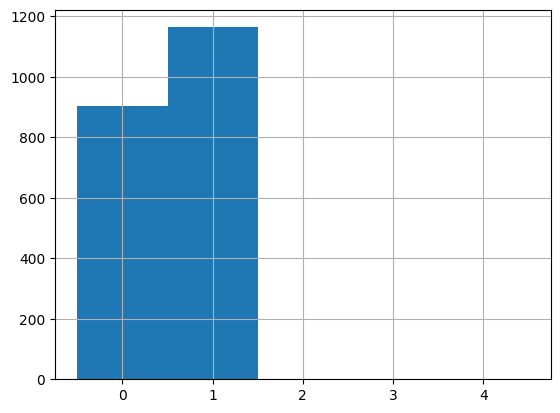

In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

outcomes = np.unique(test_df['Outcome'])
le.fit(list(set(outcomes)))
y = le.transform(test_df['Outcome'])

print("Classes                          : ", outcomes)
print("Number of cpds in each class     : ", np.unique([len(y[y == smi]) for smi in y]))
print("Total number of cpds             : ", len(y))

S = test_df['Outcome']
info = {}
for i, cls in enumerate(S.unique()):
    info.update({cls: i})
    S = S.replace(cls, i)

ax = S.hist(bins=np.arange(-0.5, 5))
ax.set_xticks(range(0, 5))
info


In [8]:
test_df = test_df.rename(columns={'labels': 'Outcome'})

In [9]:
x_data = test_df

In [10]:
test_df

,smiles,Outcome,IUPAC name,ID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES,Molecular weight,Molecule (RDKit Mol) (InChI Code),nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Molecular Weight,AMW,logP,ALogP,ALogP2,MLogP,TPSA,AMR,LabuteASA,NumLipinskiHBA,NumHBA,nHBAcc,NumLipinskiHBD,NumHBD,NumRotatableBonds,NumAmideBonds,NumHeteroAtoms,NumAtoms,NumRings,NumAromaticRings,naAromAtom,NumSaturatedRings,NumAliphaticRings,NumAromaticHeterocycles,NumSaturatedHeterocycles,NumAliphaticHeterocycles,NumAromaticCarbocycles,NumSaturatedCarbocycles,NumAliphaticCarbocycles,Chi0v,Chi1v,Chi2v,Chi3v,Chi4v,Chi1n,Chi2n,Chi3n,Chi4n,HallKierAlpha,kappa1,kappa2,kappa3,FractionCSP3,bpol,nB,ECCEN,fragC,nAtomP,Outcome,RowID
0,Cc1c(Cl)ccc(OC2CCN(C[C@H](O)CNC(=O)c3c[nH]c(=O...,0,"N-[(2R)-3-[4-(2,4-dichloro-3-methylphenoxy)pip...",,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.690806048294513, 0.2924079450017158, 0.5112...",Cc1c(Cl)ccc(OC2CCN(C[C@H](O)CNC(=O)c3c[nH]c(=O...,582.506,InChI=1S/C26H29Cl2N3O6S/c1-15-22(27)5-6-23(24(...,3,7,38.0,0.5,8,0.0,128.80,1.301182,3.18092,0.384615,582.506,582.506,3.18092,3.18092,10.118252,3.18092,128.80,147.3075,230.170792,7,7,7,3,3,8,1,12,38,4,3,3,1,1,1,1,1,2,0,0,23.289643,14.738582,12.278101,8.615918,5.505417,12.091241,9.477201,6.626484,4.443066,-2.63,28.379878,11.628461,6.495380,0.384615,553.274,8,0.0,0.0,38.0,0,0
800,CCOc1c([C@H](C)n2nc(C)c3c(N)ncnc32)cc(Cl)c(F)c...,0,"(4R)-4-[3-[(1S)-1-(4-amino-3-methylpyrazolo[3,...",,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.17780262273425018, 0.39623264933813196, 0.3...",CCOc1c([C@H](C)n2nc(C)c3c(N)ncnc32)cc(Cl)c(F)c...,432.887,InChI=1S/C20H22ClFN6O2/c1-4-30-18-12(6-13(21)1...,2,7,30.0,0.5,5,0.0,107.95,1.913936,3.12092,0.400000,432.887,432.887,3.12092,3.12092,9.740142,3.12092,107.95,111.2321,177.128961,7,7,7,2,2,5,1,10,30,4,3,3,1,1,2,1,1,1,0,0,17.625281,10.073312,7.713205,5.694645,4.229248,9.695348,7.306005,5.419617,4.009899,-2.94,20.337551,7.714161,3.225858,0.400000,410.711,5,0.0,0.0,30.0,0,800
801,Cc1cc(Cl)ccc1OC1CCN(C[C@H](O)CNC(=O)c2c[nH]c(=...,0,N-[(2R)-3-[4-(4-chloro-2-methylphenoxy)piperid...,,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.4341065701228783, 0.35130849842333645, 0.15...",Cc1cc(Cl)ccc1OC1CCN(C[C@H](O)CNC(=O)c2c[nH]c(=...,487.959,InChI=1S/C25H27ClFN3O4/c1-15-11-16(26)5-6-22(1...,3,5,34.0,0.5,7,0.0,94.66,1.264930,3.26312,0.360000,487.959,487.959,3.26312,3.26312,10.647952,3.26312,94.66,129.1457,201.042720,5,5,5,3,3,7,1,9,34,4,3,3,1,1,1,1,1,2,0,0,19.569823,11.606833,9.021792,6.290577,4.484141,11.228869,8.585356,6.055480,4.257484,-2.94,24.193022,10.546907,5.575670,0.360000,460.743,7,0.0,0.0,34.0,0,801
802,Cc1c([C@H]2CN3CCN(C(=O)Cc4ccc(-n5cnnn5)cn4)C[C...,0,"3-[(3S,9aS)-8-[2-[5-(tetrazol-1-yl)pyridin-2-y...",,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.8858027243170344, 0.9972179571316186, 0.539...",Cc1c([C@H]2CN3CCN(C(=O)Cc4ccc(-n5cnnn5)cn4)C[C...,462.489,InChI=1S/C23H23FN8O2/c1-15-19(4-5-21(24)20(15)...,0,9,34.0,0.5,4,0.0,113.06,1.190500,1.20330,0.391304,462.489,462.489,1.20330,1.20330,1.447931,1.20330,113.06,117.1390,195.104227,9,9,9,0,0,4,1,11,34,5,3,3,2,2,2,2,2,1,0,0,18.633613,11.040187,8.497812,6.517267,4.582841,11.040187,8.497812,6.517267,4.582841,-3.75,22.062563,9.244654,4.250684,0.391304,439.305,4,0.0,0.0,34.0,0,802
1634,CC1(C)Cc2c(CN3CCC4(CC3)CCN(C(=O)c3ccc(N)cn3)CC...,0,"(5-aminopyridin-2-yl)-[9-[(2,2-dimethyl-3H-1-b...",,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4437740027614739, -0.16182513647010524, -0...",CC1(C)Cc2c(CN3CCC4(CC3)CCN(C(=O)c3ccc(N)cn3)CC...,434.584,InChI=1S/C26H34N4O2/c1-25(2)16-21-19(4-3-5-23(...,1,5,32.0,0.5,3,0.0,71.69,1.155670,3.89570,0.538462,434.584,434.584,3.8

## Data Cleansing and Preproc

In [11]:
x_data = test_df.drop(columns=['smiles', 'Outcome', 'IUPAC name', 'ID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'SMILES', 'Molecular Weight',
       'Molecule (RDKit Mol) (InChI Code)','RowID','ALogP','ALogP2'])
print(x_data)

      Molecular weight  nHBDon  nAtomLAC  nAtomLC  PetitjeanNumber  nRotB  \
0              582.506       3         7     38.0              0.5      8   
800            432.887       2         7     30.0              0.5      5   
801            487.959       3         5     34.0              0.5      7   
802            462.489       0         9     34.0              0.5      4   
1634           434.584       1         5     32.0              0.5      3   
...                ...     ...       ...      ...              ...    ...   
892            419.445       2         9     31.0              0.5      4   
888            452.961       1         3     32.0              0.5      6   
887            507.566       2         8     37.0              0.5      7   
881            546.756       2         4     40.0              0.5      7   
2067           393.840       0         3     27.0              0.5      4   

      LipinskiFailures  TopoPSA   VAdjMat    XLogP      Fsp3      AMW  \
0 

In [12]:
x_data  = x_data.apply(lambda row: row.values, axis=1).tolist()

# Add the new column 'rdkit_cdk' to test_df
test_df['rdkit_cdk'] = x_data

# Display the updated DataFrame
print(test_df)

                                                 smiles Outcome  \
0     Cc1c(Cl)ccc(OC2CCN(C[C@H](O)CNC(=O)c3c[nH]c(=O...       0   
800   CCOc1c([C@H](C)n2nc(C)c3c(N)ncnc32)cc(Cl)c(F)c...       0   
801   Cc1cc(Cl)ccc1OC1CCN(C[C@H](O)CNC(=O)c2c[nH]c(=...       0   
802   Cc1c([C@H]2CN3CCN(C(=O)Cc4ccc(-n5cnnn5)cn4)C[C...       0   
1634  CC1(C)Cc2c(CN3CCC4(CC3)CCN(C(=O)c3ccc(N)cn3)CC...       0   
...                                                 ...     ...   
892   CC(C)(C)c1cc(NC(=O)c2cnc3cc(Oc4ncnc5c4CNC5)ccn...       1   
888   O=C(NCc1ccc(F)cc1)N(c1ccc(Cl)cc1)C1CCN(Cc2ccnc...       1   
887   COc1cc(C)c2ncc(F)c(CCC34CCC(NCc5ccc6c(n5)NC(=O...       1   
881   COc1ccc([C@@H](C)N[C@@H]2CC[C@@H](C(=O)N3CCC(c...       1   
2067  CN1CC[C@@H](N(Cc2ccccc2C(F)(F)F)c2ccc(C#N)c(Cl...       1   

                                             IUPAC name ID  \
0     N-[(2R)-3-[4-(2,4-dichloro-3-methylphenoxy)pip...      
800   (4R)-4-[3-[(1S)-1-(4-amino-3-methylpyrazolo[3,...      
801   N-[

In [13]:
test_df = test_df.drop(
    ['Molecule (RDKit Mol) (InChI Code)', 'ECCEN', 'nB', 'fragC'],
    axis=1
)

print(test_df)

                                                 smiles Outcome  \
0     Cc1c(Cl)ccc(OC2CCN(C[C@H](O)CNC(=O)c3c[nH]c(=O...       0   
800   CCOc1c([C@H](C)n2nc(C)c3c(N)ncnc32)cc(Cl)c(F)c...       0   
801   Cc1cc(Cl)ccc1OC1CCN(C[C@H](O)CNC(=O)c2c[nH]c(=...       0   
802   Cc1c([C@H]2CN3CCN(C(=O)Cc4ccc(-n5cnnn5)cn4)C[C...       0   
1634  CC1(C)Cc2c(CN3CCC4(CC3)CCN(C(=O)c3ccc(N)cn3)CC...       0   
...                                                 ...     ...   
892   CC(C)(C)c1cc(NC(=O)c2cnc3cc(Oc4ncnc5c4CNC5)ccn...       1   
888   O=C(NCc1ccc(F)cc1)N(c1ccc(Cl)cc1)C1CCN(Cc2ccnc...       1   
887   COc1cc(C)c2ncc(F)c(CCC34CCC(NCc5ccc6c(n5)NC(=O...       1   
881   COc1ccc([C@@H](C)N[C@@H]2CC[C@@H](C(=O)N3CCC(c...       1   
2067  CN1CC[C@@H](N(Cc2ccccc2C(F)(F)F)c2ccc(C#N)c(Cl...       1   

                                             IUPAC name ID  \
0     N-[(2R)-3-[4-(2,4-dichloro-3-methylphenoxy)pip...      
800   (4R)-4-[3-[(1S)-1-(4-amino-3-methylpyrazolo[3,...      
801   N-[

In [14]:
test_df = test_df.loc[:,~test_df.columns.duplicated()]
y_true = test_df['Outcome'].astype(int).values


## Data Initiate

In [15]:
y_test= np.int32((S))
x_test_morgan = np.array(list(test_df['Morgan_Descriptors']))
x_test_macckeys = np.array(list(test_df['MACCS_Descriptors']))
x_test_modred= np.array(list(test_df['Modred_Descriptor']))
x_test_rdkit_cdk = np.array(list(test_df['rdkit_cdk']))

In [16]:
x_test_rdkit_cdk

array([[582.506,   3.   ,   7.   , ...,   0.   ,   0.   ,  38.   ],
       [432.887,   2.   ,   7.   , ...,   0.   ,   0.   ,  30.   ],
       [487.959,   3.   ,   5.   , ...,   0.   ,   0.   ,  34.   ],
       ...,
       [507.566,   2.   ,   8.   , ...,   0.   ,   0.   ,  37.   ],
       [546.756,   2.   ,   4.   , ...,   0.   ,   0.   ,  40.   ],
       [393.84 ,   0.   ,   3.   , ...,   0.   ,   0.   ,  27.   ]])

In [17]:
import joblib
import numpy as np
import ast

# Function to ensure data is a NumPy array
def ensure_numpy_array(data):
    if isinstance(data, np.ndarray):
        return data
    elif isinstance(data, list):
        return np.array(data)
    elif hasattr(data, 'to_numpy'):  # For Pandas DataFrame
        return data.to_numpy()
    else:
        raise ValueError("Data format not recognized. Ensure it is a list, numpy array, or pandas DataFrame.")

# Function to check if all elements are numerical
def check_numerical(data):
    if not np.issubdtype(data.dtype, np.number):
        raise ValueError("Data contains non-numerical values. Ensure all elements are numerical.")

# Function to convert string representations of lists to numerical arrays
def parse_string_lists(data):
    parsed_data = []
    for item in data:
        if isinstance(item, str):
            try:
                parsed_item = ast.literal_eval(item)
                parsed_data.append(parsed_item)
            except (ValueError, SyntaxError):
                raise ValueError(f"Cannot parse value '{item}'")
        else:
            parsed_data.append(item)
    return np.array(parsed_data)

# Ensure training data is properly formatted
x_test_morgan = ensure_numpy_array(x_test_morgan)
x_test_macckeys = ensure_numpy_array(x_test_macckeys)
x_test_modred = ensure_numpy_array(x_test_modred)

check_numerical(x_test_morgan)
check_numerical(x_test_macckeys)

# Parse and convert string lists in x_test_modred
x_test_modred = parse_string_lists(x_test_modred)
check_numerical(x_test_modred)





In [18]:
x_test = np.concatenate((x_test_morgan, x_test_macckeys, x_test_modred), axis=1)

## Load .pkl Model

In [19]:
#load model - all included
import joblib

# Base paths
fingerprint_path = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Cardiac toxicity\model\fingerprint descriptor model"
phys_path        = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Cardiac toxicity\model\physical chemical properties model"

# descriptor
rf_morgan   = joblib.load(fr"{fingerprint_path}\Model_Cardiac_RF_morgan.pkl")  
rf_maccs    = joblib.load(fr"{fingerprint_path}\Model_Cardiac_RF_maccs.pkl")
rf_modred   = joblib.load(fr"{fingerprint_path}\Model_Cardiac_RF_modred.pkl")

svm_morgan  = joblib.load(fr"{fingerprint_path}\Model_Cardiac_SVM_morgan.pkl")  
svm_maccs   = joblib.load(fr"{fingerprint_path}\Model_Cardiac_SVM_maccs.pkl")
svm_modred  = joblib.load(fr"{fingerprint_path}\Model_Cardiac_SVM_modred.pkl")

xgb_morgan  = joblib.load(fr"{fingerprint_path}\Model_Cardiac_XGB_morgan.pkl")  
xgb_maccs   = joblib.load(fr"{fingerprint_path}\Model_Cardiac_XGB_maccs.pkl")
xgb_modred  = joblib.load(fr"{fingerprint_path}\Model_Cardiac_XGB_modred.pkl")

nn_morgan   = joblib.load(fr"{fingerprint_path}\Model_Cardiac_NN_morgan.pkl")  
nn_maccs    = joblib.load(fr"{fingerprint_path}\Model_Cardiac_NN_maccs.pkl")
nn_modred   = joblib.load(fr"{fingerprint_path}\Model_Cardiac_NN_modred.pkl")

lgbm_morgan = joblib.load(fr"{fingerprint_path}\Model_Cardiac_LGBM_morgan.pkl")  
lgbm_maccs  = joblib.load(fr"{fingerprint_path}\Model_Cardiac_LGBM_maccs.pkl")
lgbm_modred = joblib.load(fr"{fingerprint_path}\Model_Cardiac_LGBM_modred.pkl")

# physiochemical
rf_p   = joblib.load(fr"{phys_path}\Model_Cardiac_RF_phys.pkl")
svm_p  = joblib.load(fr"{phys_path}\Model_Cardiac_SVM_phys.pkl")
xgb_p  = joblib.load(fr"{phys_path}\Model_Cardiac_XGB_phys.pkl")
nn_p   = joblib.load(fr"{phys_path}\Model_Cardiac_NN_phys.pkl")
lgbm_p = joblib.load(fr"{phys_path}\Model_Cardiac_LGBM_phys.pkl")


In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score, classification_report
y_true = test_df['Outcome'].astype(int)  # Ensure it's of integer type, suitable for metrics calculation


## Physiochemical Consensus and Individual

In [21]:
#Default

import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):
  
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]  # Probabilities for class 1
    xgb_probs_rdkitcdk = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]  # Probabilities for class 1
    svm_probs_rdkitcdk = svm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]  # Probabilities for class 1
    
    # Calculate the mean probability across RF and XGB models
    mean_probs = np.mean([rf_probs_rdkitcdk, xgb_probs_rdkitcdk], axis=0)
    
    # Convert mean probabilities to final class predictions (e.g., threshold at 0.5)
    final_predictions = (mean_probs > 0.5).astype(int)
    
    return final_predictions, mean_probs, rf_probs_rdkitcdk, xgb_probs_rdkitcdk, svm_probs_rdkitcdk

# Run prediction
final_predictions, mean_probs, rf_probs, xgb_probs, svm_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
test_df['RF_Probabilities'] = rf_probs
test_df['XGB_Probabilities'] = xgb_probs
test_df['SVM_Probabilities'] = svm_probs

y_true = test_df['Outcome'].astype(int)  

conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix (Consensus):")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy (Consensus):", accuracy)

auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score (Consensus):", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')  
print("F1 Score (Consensus):", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity (Consensus):", sensitivity)
print("Specificity (Consensus):", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate) (Consensus):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp)
print("PPV (Positive Predictive Value) (Consensus):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn)
print("NPV (Negative Predictive Value) (Consensus):", npv)

# Evaluate RF model alone
rf_predictions = (rf_probs > 0.5).astype(int)
conf_matrix_rf = confusion_matrix(y_true, rf_predictions)
print("Confusion Matrix (RF):")
print(conf_matrix_rf)

accuracy_rf = accuracy_score(y_true, rf_predictions)
print("Accuracy (RF):", accuracy_rf)

auc_score_rf = roc_auc_score(y_true, rf_probs)
print("AUC Score (RF):", auc_score_rf)

f1_rf = f1_score(y_true, rf_predictions, average='binary')
print("F1 Score (RF):", f1_rf)

tn, fp, fn, tp = conf_matrix_rf.ravel()
sensitivity_rf = tp / (tp + fn)
specificity_rf = tn / (tn + fp)
print("Sensitivity (RF):", sensitivity_rf)
print("Specificity (RF):", specificity_rf)

ccr_rf = (sensitivity_rf + specificity_rf) / 2
print("CCR (Correct Classification Rate) (RF):", ccr_rf)

ppv_rf = tp / (tp + fp)
print("PPV (Positive Predictive Value) (RF):", ppv_rf)

npv_rf = tn / (tn + fn)
print("NPV (Negative Predictive Value) (RF):", npv_rf)

# Evaluate XGB model alone
xgb_predictions = (xgb_probs > 0.5).astype(int)
conf_matrix_xgb = confusion_matrix(y_true, xgb_predictions)
print("Confusion Matrix (XGB):")
print(conf_matrix_xgb)

accuracy_xgb = accuracy_score(y_true, xgb_predictions)
print("Accuracy (XGB):", accuracy_xgb)

auc_score_xgb = roc_auc_score(y_true, xgb_probs)
print("AUC Score (XGB):", auc_score_xgb)

f1_xgb = f1_score(y_true, xgb_predictions, average='binary')
print("F1 Score (XGB):", f1_xgb)

tn, fp, fn, tp = conf_matrix_xgb.ravel()
sensitivity_xgb = tp / (tp + fn)
specificity_xgb = tn / (tn + fp)
print("Sensitivity (XGB):", sensitivity_xgb)
print("Specificity (XGB):", specificity_xgb)

ccr_xgb = (sensitivity_xgb + specificity_xgb) / 2
print("CCR (Correct Classification Rate) (XGB):", ccr_xgb)

ppv_xgb = tp / (tp + fp)
print("PPV (Positive Predictive Value) (XGB):", ppv_xgb)

npv_xgb = tn / (tn + fn)
print("NPV (Negative Predictive Value) (XGB):", npv_xgb)

# Evaluate SVM model alone
svm_predictions = (svm_probs > 0.5).astype(int)
conf_matrix_svm = confusion_matrix(y_true, svm_predictions)
print("Confusion Matrix (SVM):")
print(conf_matrix_svm)

accuracy_svm = accuracy_score(y_true, svm_predictions)
print("Accuracy (SVM):", accuracy_svm)

auc_score_svm = roc_auc_score(y_true, svm_probs)
print("AUC Score (SVM):", auc_score_svm)

f1_svm = f1_score(y_true, svm_predictions, average='binary')
print("F1 Score (SVM):", f1_svm)

tn, fp, fn, tp = conf_matrix_svm.ravel()
sensitivity_svm = tp / (tp + fn)
specificity_svm = tn / (tn + fp)
print("Sensitivity (SVM):", sensitivity_svm)
print("Specificity (SVM):", specificity_svm)

ccr_svm = (sensitivity_svm + specificity_svm) / 2
print("CCR (Correct Classification Rate) (SVM):", ccr_svm)

ppv_svm = tp / (tp + fp)
print("PPV (Positive Predictive Value) (SVM):", ppv_svm)

npv_svm = tn / (tn + fn)
print("NPV (Negative Predictive Value) (SVM):", npv_svm)

Confusion Matrix (Consensus):
[[605 299]
 [185 979]]
Accuracy (Consensus): 0.7659574468085106
AUC Score (Consensus): 0.8434192819998175
F1 Score (Consensus): 0.8018018018018018
Sensitivity (Consensus): 0.8410652920962199
Specificity (Consensus): 0.6692477876106194
CCR (Correct Classification Rate) (Consensus): 0.7551565398534197
PPV (Positive Predictive Value) (Consensus): 0.7660406885758998
NPV (Negative Predictive Value) (Consensus): 0.7658227848101266
Confusion Matrix (RF):
[[595 309]
 [177 987]]
Accuracy (RF): 0.7649903288201161
AUC Score (RF): 0.8403435095642126
F1 Score (RF): 0.802439024390244
Sensitivity (RF): 0.8479381443298969
Specificity (RF): 0.6581858407079646
CCR (Correct Classification Rate) (RF): 0.7530619925189308
PPV (Positive Predictive Value) (RF): 0.7615740740740741
NPV (Negative Predictive Value) (RF): 0.7707253886010362
Confusion Matrix (XGB):
[[603 301]
 [198 966]]
Accuracy (XGB): 0.7587040618955513
AUC Score (XGB): 0.8354492632971444
F1 Score (XGB): 0.7947346770

In [22]:
#best choice maybe
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):
    X_test = np.array(test_df['rdkit_cdk'].tolist())

    rf_probs = rf_p.predict_proba(X_test)[:, 1]
    xgb_probs = xgb_p.predict_proba(X_test)[:, 1]
    svm_probs = svm_p.predict_proba(X_test)[:, 1]
    nn_probs = nn_p.predict_proba(X_test)[:, 1]
    lgbm_probs = lgbm_p.predict_proba(X_test)[:, 1]

    # Calculate the mean probability across all 5 models
    mean_probs = np.mean([rf_probs, xgb_probs, svm_probs, nn_probs, lgbm_probs], axis=0)

    # Convert mean probabilities to final class predictions (threshold at 0.5)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs, rf_probs, xgb_probs, svm_probs, nn_probs, lgbm_probs

# Run prediction
final_predictions, mean_probs, rf_probs, xgb_probs, svm_probs, nn_probs, lgbm_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
test_df['RF_Probabilities'] = rf_probs
test_df['XGB_Probabilities'] = xgb_probs
test_df['SVM_Probabilities'] = svm_probs
test_df['NN_Probabilities'] = nn_probs
test_df['LGBM_Probabilities'] = lgbm_probs

y_true = test_df['Outcome'].astype(int)


def evaluate_model(y_true, probs, label):
    predictions = (probs > 0.5).astype(int)
    cm = confusion_matrix(y_true, predictions)
    print(f"Confusion Matrix ({label}):")
    print(cm)

    accuracy = accuracy_score(y_true, predictions)
    print(f"Accuracy ({label}):", accuracy)

    auc_score = roc_auc_score(y_true, probs)
    print(f"AUC Score ({label}):", auc_score)

    f1 = f1_score(y_true, predictions, average='binary')
    print(f"F1 Score ({label}):", f1)

    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    print(f"Sensitivity ({label}):", sensitivity)
    print(f"Specificity ({label}):", specificity)

    ccr = (sensitivity + specificity) / 2
    print(f"CCR (Correct Classification Rate) ({label}):", ccr)

    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"PPV (Positive Predictive Value) ({label}):", ppv)

    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    print(f"NPV (Negative Predictive Value) ({label}):", npv)

    print()  # spacer antar model
    return {
        "accuracy": accuracy, "auc": auc_score, "f1": f1,
        "sensitivity": sensitivity, "specificity": specificity,
        "ccr": ccr, "ppv": ppv, "npv": npv
    }


# Evaluate consensus and each individual model
results_consensus = evaluate_model(y_true, mean_probs, "Consensus")
results_rf = evaluate_model(y_true, rf_probs, "RF")
results_xgb = evaluate_model(y_true, xgb_probs, "XGB")
results_svm = evaluate_model(y_true, svm_probs, "SVM")
results_nn = evaluate_model(y_true, nn_probs, "NN")
results_lgbm = evaluate_model(y_true, lgbm_probs, "LGBM")

Confusion Matrix (Consensus):
[[607 297]
 [184 980]]
Accuracy (Consensus): 0.7674081237911026
AUC Score (Consensus): 0.8415803758781133
F1 Score (Consensus): 0.8029496108152396
Sensitivity (Consensus): 0.8419243986254296
Specificity (Consensus): 0.6714601769911505
CCR (Correct Classification Rate) (Consensus): 0.75669228780829
PPV (Positive Predictive Value) (Consensus): 0.7674236491777604
NPV (Negative Predictive Value) (Consensus): 0.7673830594184576

Confusion Matrix (RF):
[[595 309]
 [177 987]]
Accuracy (RF): 0.7649903288201161
AUC Score (RF): 0.8403435095642126
F1 Score (RF): 0.802439024390244
Sensitivity (RF): 0.8479381443298969
Specificity (RF): 0.6581858407079646
CCR (Correct Classification Rate) (RF): 0.7530619925189308
PPV (Positive Predictive Value) (RF): 0.7615740740740741
NPV (Negative Predictive Value) (RF): 0.7707253886010362

Confusion Matrix (XGB):
[[603 301]
 [198 966]]
Accuracy (XGB): 0.7587040618955513
AUC Score (XGB): 0.8354492632971444
F1 Score (XGB): 0.7947346770

## Proof of Consensus

In [23]:
#best choice maybe
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):
    X_test = np.array(test_df['rdkit_cdk'].tolist())

    rf_probs = rf_p.predict_proba(X_test)[:, 1]
    xgb_probs = xgb_p.predict_proba(X_test)[:, 1]
    svm_probs = svm_p.predict_proba(X_test)[:, 1]
    nn_probs = nn_p.predict_proba(X_test)[:, 1]
    lgbm_probs = lgbm_p.predict_proba(X_test)[:, 1]

    # Calculate the mean probability across all 5 models
    mean_probs = np.mean([rf_probs, xgb_probs, svm_probs, nn_probs, lgbm_probs], axis=0)

    # Convert mean probabilities to final class predictions (threshold at 0.5)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs, rf_probs, xgb_probs, svm_probs, nn_probs, lgbm_probs

# Run prediction
final_predictions, mean_probs, rf_probs, xgb_probs, svm_probs, nn_probs, lgbm_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
test_df['RF_Probabilities'] = rf_probs
test_df['XGB_Probabilities'] = xgb_probs
test_df['SVM_Probabilities'] = svm_probs
test_df['NN_Probabilities'] = nn_probs
test_df['LGBM_Probabilities'] = lgbm_probs

print("\n")
print("="*80)
print("Manual Verification of Consensus Probability")
print("="*80)

for i in range(5):
    rf = rf_probs[i]
    xgb = xgb_probs[i]
    svm = svm_probs[i]
    nn = nn_probs[i]
    lgbm = lgbm_probs[i]

    mean_manual = (rf + xgb + svm + nn + lgbm) / 5

    print(f"\nSample {i+1}")
    print(f"Outcome           : {y_true.iloc[i]}")
    print(f"RF Probability    : {rf:.4f}")
    print(f"XGB Probability   : {xgb:.4f}")
    print(f"SVM Probability   : {svm:.4f}")
    print(f"NN Probability    : {nn:.4f}")
    print(f"LGBM Probability  : {lgbm:.4f}")
    print(f"Mean Probability  : {mean_manual:.4f}")
    print(f"Prediction        : {1 if mean_manual > 0.5 else 0}")

y_true = test_df['Outcome'].astype(int)


def evaluate_model(y_true, probs, label):
    predictions = (probs > 0.5).astype(int)
    cm = confusion_matrix(y_true, predictions)
    print(f"Confusion Matrix ({label}):")
    print(cm)

    accuracy = accuracy_score(y_true, predictions)
    print(f"Accuracy ({label}):", accuracy)

    auc_score = roc_auc_score(y_true, probs)
    print(f"AUC Score ({label}):", auc_score)

    f1 = f1_score(y_true, predictions, average='binary')
    print(f"F1 Score ({label}):", f1)

    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    print(f"Sensitivity ({label}):", sensitivity)
    print(f"Specificity ({label}):", specificity)

    ccr = (sensitivity + specificity) / 2
    print(f"CCR (Correct Classification Rate) ({label}):", ccr)

    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"PPV (Positive Predictive Value) ({label}):", ppv)

    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    print(f"NPV (Negative Predictive Value) ({label}):", npv)

    print()  # spacer antar model
    return {
        "accuracy": accuracy, "auc": auc_score, "f1": f1,
        "sensitivity": sensitivity, "specificity": specificity,
        "ccr": ccr, "ppv": ppv, "npv": npv
    }


# Evaluate consensus and each individual model
results_consensus = evaluate_model(y_true, mean_probs, "Consensus")
results_rf = evaluate_model(y_true, rf_probs, "RF")
results_xgb = evaluate_model(y_true, xgb_probs, "XGB")
results_svm = evaluate_model(y_true, svm_probs, "SVM")
results_nn = evaluate_model(y_true, nn_probs, "NN")
results_lgbm = evaluate_model(y_true, lgbm_probs, "LGBM")



Manual Verification of Consensus Probability

Sample 1
Outcome           : 0
RF Probability    : 0.3167
XGB Probability   : 0.1421
SVM Probability   : 0.2094
NN Probability    : 0.3068
LGBM Probability  : 0.3700
Mean Probability  : 0.2690
Prediction        : 0

Sample 2
Outcome           : 0
RF Probability    : 0.4303
XGB Probability   : 0.3363
SVM Probability   : 0.4476
NN Probability    : 0.3794
LGBM Probability  : 0.4099
Mean Probability  : 0.4007
Prediction        : 0

Sample 3
Outcome           : 0
RF Probability    : 0.7233
XGB Probability   : 0.9572
SVM Probability   : 0.6026
NN Probability    : 0.4020
LGBM Probability  : 0.7405
Mean Probability  : 0.6851
Prediction        : 1

Sample 4
Outcome           : 0
RF Probability    : 0.2281
XGB Probability   : 0.3849
SVM Probability   : 0.4282
NN Probability    : 0.2313
LGBM Probability  : 0.3839
Mean Probability  : 0.3313
Prediction        : 0

Sample 5
Outcome           : 0
RF Probability    : 0.1867
XGB Probability   : 0.1148
SVM

## Consensus Physiochemical and Mol Desc

In [24]:
#Persis dengan bu yunen
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = rf_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = rf_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs_rdkitcdk = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs, xgb_probs_rdkitcdk], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
y_true = test_df['Outcome'].astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

# Calculate AUC using mean probabilities
auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[ 643  261]
 [ 156 1008]]
Accuracy: 0.7983558994197292
AUC Score: 0.8820315588602012
F1 Score: 0.8286066584463625
Sensitivity: 0.865979381443299
Specificity: 0.7112831858407079
CCR (Correct Classification Rate): 0.7886312836420035
PPV (Positive Predictive Value): 0.7943262411347518
NPV (Negative Predictive Value): 0.804755944931164


In [25]:
#rf xgb svm(p) rf(p)
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = xgb_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = svm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs_rdkitcdk = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs, xgb_probs_rdkitcdk], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
y_true = test_df['Outcome'].astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

# Calculate AUC using mean probabilities
auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[ 660  244]
 [ 163 1001]]
Accuracy: 0.8031914893617021
AUC Score: 0.8853739014080225
F1 Score: 0.8310502283105022
Sensitivity: 0.8599656357388317
Specificity: 0.7300884955752213
CCR (Correct Classification Rate): 0.7950270656570264
PPV (Positive Predictive Value): 0.8040160642570281
NPV (Negative Predictive Value): 0.8019441069258809


In [26]:
#best
# rf xgb svm nn(p) lgbm(p)
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = xgb_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = svm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    nn_probs_rdkitcdk = nn_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs_rdkitcdk = lgbm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs, lgbm_probs_rdkitcdk, nn_probs_rdkitcdk], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
y_true = test_df['Outcome'].astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

# Calculate AUC using mean probabilities
auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[675 229]
 [165 999]]
Accuracy: 0.809477756286267
AUC Score: 0.8856466487242649
F1 Score: 0.8352842809364549
Sensitivity: 0.8582474226804123
Specificity: 0.7466814159292036
CCR (Correct Classification Rate): 0.8024644193048079
PPV (Positive Predictive Value): 0.8135179153094463
NPV (Negative Predictive Value): 0.8035714285714286


In [27]:
#rf xgb svm(p) rf(p)
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = xgb_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = svm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs_rdkitcdk = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs_rdkitcdk = lgbm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    svm_probs_rdkitcdk = svm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]


    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs, lgbm_probs_rdkitcdk, xgb_probs_rdkitcdk, rf_probs_rdkitcdk], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
y_true = test_df['Outcome'].astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

# Calculate AUC using mean probabilities
auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[658 246]
 [169 995]]
Accuracy: 0.7993230174081238
AUC Score: 0.8807200909284432
F1 Score: 0.8274428274428275
Sensitivity: 0.8548109965635738
Specificity: 0.7278761061946902
CCR (Correct Classification Rate): 0.791343551379132
PPV (Positive Predictive Value): 0.8017727639000806
NPV (Negative Predictive Value): 0.7956469165659008


## Best Result RF LGBM XGB

In [28]:
#rf xgb svm(p) rf(p)
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = lgbm_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = lgbm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs_rdkitcdk = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs_rdkitcdk = lgbm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]


    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs, lgbm_probs_rdkitcdk, rf_probs_rdkitcdk], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
y_true = test_df['Outcome'].astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

# Calculate AUC using mean probabilities
auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[686 218]
 [167 997]]
Accuracy: 0.8138297872340425
AUC Score: 0.8909001231639448
F1 Score: 0.8381672971836907
Sensitivity: 0.8565292096219931
Specificity: 0.7588495575221239
CCR (Correct Classification Rate): 0.8076893835720584
PPV (Positive Predictive Value): 0.8205761316872427
NPV (Negative Predictive Value): 0.8042203985932005


In [31]:
#rf xgb svm(p) rf(p)
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = xgb_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = lgbm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs_rdkitcdk = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs_rdkitcdk = lgbm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]


    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs, lgbm_probs_rdkitcdk,xgb_probs_rdkitcdk, rf_probs_rdkitcdk], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
y_true = test_df['Outcome'].astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

# Calculate AUC using mean probabilities
auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[ 668  236]
 [ 158 1006]]
Accuracy: 0.809477756286267
AUC Score: 0.8840747878843171
F1 Score: 0.8362427265170407
Sensitivity: 0.8642611683848798
Specificity: 0.7389380530973452
CCR (Correct Classification Rate): 0.8015996107411125
PPV (Positive Predictive Value): 0.8099838969404187
NPV (Negative Predictive Value): 0.8087167070217918


## Read Accross

In [29]:
#Read-Across (Tanimoto Similarity, Morgan Fingerprint, k=5, weighted) - 

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score
from rdkit import DataStructs
from rdkit.DataStructs import ExplicitBitVect

# ===== Load train_df =====
train_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Cardiac toxicity\dataset\test_set_acute_cardiotoxicity_features.sdf')

def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

train_df = train_df.rename(columns={"labels": "Outcome"})


train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)

print("Train DataFrame:")
print(train_df.head())
print(train_df.shape)


# ===== Fungsi Read-Across =====
def tanimoto_similarity_matrix(query_fps, ref_fps):
    n_query = query_fps.shape[0]
    n_ref = ref_fps.shape[0]
    sim_matrix = np.zeros((n_query, n_ref))

    ref_bitvecs = []
    for row in ref_fps:
        bv = ExplicitBitVect(len(row))
        on_bits = np.where(row == 1)[0].tolist()
        bv.SetBitsFromList(on_bits)
        ref_bitvecs.append(bv)

    for i, q_row in enumerate(query_fps):
        q_bv = ExplicitBitVect(len(q_row))
        q_on_bits = np.where(q_row == 1)[0].tolist()
        q_bv.SetBitsFromList(q_on_bits)
        sims = DataStructs.BulkTanimotoSimilarity(q_bv, ref_bitvecs)
        sim_matrix[i, :] = sims

    return sim_matrix


def read_across_predict(X_test_fp, X_train_fp, y_train, k=5):
    sim_matrix = tanimoto_similarity_matrix(X_test_fp, X_train_fp)
    predictions_proba = np.zeros(X_test_fp.shape[0])

    for i in range(X_test_fp.shape[0]):
        sims = sim_matrix[i, :]
        top_k_idx = np.argsort(sims)[::-1][:k]
        top_k_sims = sims[top_k_idx]
        top_k_labels = y_train[top_k_idx]

        total_sim = np.sum(top_k_sims)
        if total_sim > 0:
            weighted_pred = np.sum(top_k_sims * top_k_labels) / total_sim
        else:
            weighted_pred = np.mean(top_k_labels)
        predictions_proba[i] = weighted_pred

    return predictions_proba


# ===== Siapkan data =====
X_train_morgan = np.array(train_df['Morgan_Descriptors'].tolist())
y_train = pd.to_numeric(train_df['Outcome'], errors='coerce').astype(int).values

X_test_morgan = np.array(test_df['Morgan_Descriptors'].tolist())
y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)

# ===== Jalankan read-across =====
readacross_probs = read_across_predict(X_test_morgan, X_train_morgan, y_train, k=5)
readacross_predictions = (readacross_probs > 0.5).astype(int)

test_df['ReadAcross_Probabilities'] = readacross_probs
test_df['ReadAcross_Predictions'] = readacross_predictions

# ===== Evaluasi =====
conf_matrix_ra = confusion_matrix(y_true, readacross_predictions)
print("Confusion Matrix (Read-Across):")
print(conf_matrix_ra)

accuracy_ra = accuracy_score(y_true, readacross_predictions)
print("Accuracy (Read-Across):", accuracy_ra)

auc_score_ra = roc_auc_score(y_true, readacross_probs)
print("AUC Score (Read-Across):", auc_score_ra)

f1_ra = f1_score(y_true, readacross_predictions, average='binary')
print("F1 Score (Read-Across):", f1_ra)

tn, fp, fn, tp = conf_matrix_ra.ravel()
sensitivity_ra = tp / (tp + fn)
specificity_ra = tn / (tn + fp)
print("Sensitivity (Read-Across):", sensitivity_ra)
print("Specificity (Read-Across):", specificity_ra)

ccr_ra = (sensitivity_ra + specificity_ra) / 2
print("CCR (Correct Classification Rate) (Read-Across):", ccr_ra)

ppv_ra = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value) (Read-Across):", ppv_ra)

npv_ra = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value) (Read-Across):", npv_ra)

Train DataFrame:
                                              smiles Outcome  \
0  Cc1c(Cl)ccc(OC2CCN(C[C@H](O)CNC(=O)c3c[nH]c(=O...       0   
1  Cc1ccc(C(=O)N2CCN(c3ccc(OCCCN4CCCCC4)cc3)C(=O)...       0   
2  O=C(Nc1ccc(F)cn1)[C@H](COCCO)Oc1ncnc2c1cnn2-c1...       0   
3  CC(=O)NC[C@@H]1OC(=O)N2c3cc(F)c(C4=CCN(C(=O)CO...       0   
4  CCC(NCCCC[C@@H](C[C@@H](OC)c1ccc(F)cc1)C(=O)NO...       1   

                                          IUPAC name ID  \
0  N-[(2R)-3-[4-(2,4-dichloro-3-methylphenoxy)pip...      
1  4-(4-methylbenzoyl)-1-[4-(3-piperidin-1-ylprop...      
2  (2S)-2-[1-(2-chlorophenyl)pyrazolo[3,4-d]pyrim...      
3  N-[[(3S,3aS)-8-fluoro-7-[1-(2-hydroxyacetyl)-3...      
4  (2S)-2-[(2R)-2-(4-fluorophenyl)-2-methoxyethyl...      

                                  Morgan_Descriptors  \
0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, ...   
2  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   
3  [0, 0, 0, 0, 0, 

## Checking for dataset naming

## QRASAR Morgan

In [30]:
#rf xgb svm(p) rf(p) + read-across
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score
from rdkit import DataStructs
from rdkit.DataStructs import ExplicitBitVect

# ===== Fungsi Read-Across =====
def tanimoto_similarity_matrix(query_fps, ref_fps):
    n_query = query_fps.shape[0]
    n_ref = ref_fps.shape[0]
    sim_matrix = np.zeros((n_query, n_ref))

    ref_bitvecs = []
    for row in ref_fps:
        bv = ExplicitBitVect(len(row))
        on_bits = np.where(row == 1)[0].tolist()
        bv.SetBitsFromList(on_bits)
        ref_bitvecs.append(bv)

    for i, q_row in enumerate(query_fps):
        q_bv = ExplicitBitVect(len(q_row))
        q_on_bits = np.where(q_row == 1)[0].tolist()
        q_bv.SetBitsFromList(q_on_bits)
        sims = DataStructs.BulkTanimotoSimilarity(q_bv, ref_bitvecs)
        sim_matrix[i, :] = sims

    return sim_matrix


def read_across_predict(X_test_fp, X_train_fp, y_train, k=5):
    sim_matrix = tanimoto_similarity_matrix(X_test_fp, X_train_fp)
    predictions_proba = np.zeros(X_test_fp.shape[0])

    for i in range(X_test_fp.shape[0]):
        sims = sim_matrix[i, :]
        top_k_idx = np.argsort(sims)[::-1][:k]
        top_k_sims = sims[top_k_idx]
        top_k_labels = y_train[top_k_idx]

        total_sim = np.sum(top_k_sims)
        if total_sim > 0:
            weighted_pred = np.sum(top_k_sims * top_k_labels) / total_sim
        else:
            weighted_pred = np.mean(top_k_labels)
        predictions_proba[i] = weighted_pred

    return predictions_proba


# ===== Fungsi konsensus utama =====
def predict_with_models_probabilities(test_df, train_df, k_readacross=5):
    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = lgbm_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = lgbm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs_rdkitcdk = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs_rdkitcdk = lgbm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # ----- Read-Across -----
    X_train_morgan = np.array(train_df['Morgan_Descriptors'].tolist())
    y_train_ra = pd.to_numeric(train_df['Outcome'], errors='coerce').astype(int).values
    X_test_morgan = np.array(test_df['Morgan_Descriptors'].tolist())

    readacross_probs = read_across_predict(X_test_morgan, X_train_morgan, y_train_ra, k=k_readacross)

    # ----- Konsensus (7 komponen) -----
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs,lgbm_probs_rdkitcdk, xgb_probs_rdkitcdk, rf_probs_rdkitcdk,
    readacross_probs,readacross_probs
    ], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs, readacross_probs


# Run prediction
final_predictions, mean_probs, readacross_probs = predict_with_models_probabilities(test_df, train_df, k_readacross=5)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
test_df['ReadAcross_Probabilities'] = readacross_probs

y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[ 722  182]
 [ 122 1042]]
Accuracy: 0.8529980657640233
AUC Score: 0.935528996746039
F1 Score: 0.8726968174204355
Sensitivity: 0.8951890034364262
Specificity: 0.7986725663716814
CCR (Correct Classification Rate): 0.8469307849040537
PPV (Positive Predictive Value): 0.8513071895424836
NPV (Negative Predictive Value): 0.8554502369668247


## QRASAR Maccs keys

In [31]:
#rf xgb svm(p) rf(p) + read-across
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score
from rdkit import DataStructs
from rdkit.DataStructs import ExplicitBitVect

# ===== Fungsi Read-Across =====
def tanimoto_similarity_matrix(query_fps, ref_fps):
    n_query = query_fps.shape[0]
    n_ref = ref_fps.shape[0]
    sim_matrix = np.zeros((n_query, n_ref))

    ref_bitvecs = []
    for row in ref_fps:
        bv = ExplicitBitVect(len(row))
        on_bits = np.where(row == 1)[0].tolist()
        bv.SetBitsFromList(on_bits)
        ref_bitvecs.append(bv)

    for i, q_row in enumerate(query_fps):
        q_bv = ExplicitBitVect(len(q_row))
        q_on_bits = np.where(q_row == 1)[0].tolist()
        q_bv.SetBitsFromList(q_on_bits)
        sims = DataStructs.BulkTanimotoSimilarity(q_bv, ref_bitvecs)
        sim_matrix[i, :] = sims

    return sim_matrix


def read_across_predict(X_test_fp, X_train_fp, y_train, k=5):
    sim_matrix = tanimoto_similarity_matrix(X_test_fp, X_train_fp)
    predictions_proba = np.zeros(X_test_fp.shape[0])

    for i in range(X_test_fp.shape[0]):
        sims = sim_matrix[i, :]
        top_k_idx = np.argsort(sims)[::-1][:k]
        top_k_sims = sims[top_k_idx]
        top_k_labels = y_train[top_k_idx]

        total_sim = np.sum(top_k_sims)
        if total_sim > 0:
            weighted_pred = np.sum(top_k_sims * top_k_labels) / total_sim
        else:
            weighted_pred = np.mean(top_k_labels)
        predictions_proba[i] = weighted_pred

    return predictions_proba


# ===== Fungsi konsensus utama =====
def predict_with_models_probabilities(test_df, train_df, k_readacross=5):
    morgan_probs = lgbm_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = lgbm_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = lgbm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    rf_probs_rdkitcdk = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs_rdkitcdk = lgbm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    svm_probs_rdkitcdk = svm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # ----- Read-Across -----
    X_train_maccs = np.array(train_df['MACCS_Descriptors'].tolist())
    y_train_ra = pd.to_numeric(train_df['Outcome'], errors='coerce').astype(int).values
    X_test_maccs = np.array(test_df['MACCS_Descriptors'].tolist())

    readacross_probs = read_across_predict(X_test_maccs, X_train_maccs, y_train_ra, k=k_readacross)

    # ----- Konsensus (7 komponen) -----
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs,lgbm_probs_rdkitcdk, svm_probs_rdkitcdk, rf_probs_rdkitcdk,
    readacross_probs,readacross_probs
    ], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs, readacross_probs


# Run prediction
final_predictions, mean_probs, readacross_probs = predict_with_models_probabilities(test_df, train_df, k_readacross=5)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
test_df['ReadAcross_Probabilities'] = readacross_probs

y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[ 724  180]
 [ 133 1031]]
Accuracy: 0.8486460348162476
AUC Score: 0.9242893364352402
F1 Score: 0.8682105263157894
Sensitivity: 0.8857388316151202
Specificity: 0.8008849557522124
CCR (Correct Classification Rate): 0.8433118936836663
PPV (Positive Predictive Value): 0.8513625103220479
NPV (Negative Predictive Value): 0.8448074679113186


## XAI Test

Menghitung SHAP values RF...
Shape shap_values_rf.values: (2068, 56, 2)
Diambil class 1, shape final: (2068, 56)


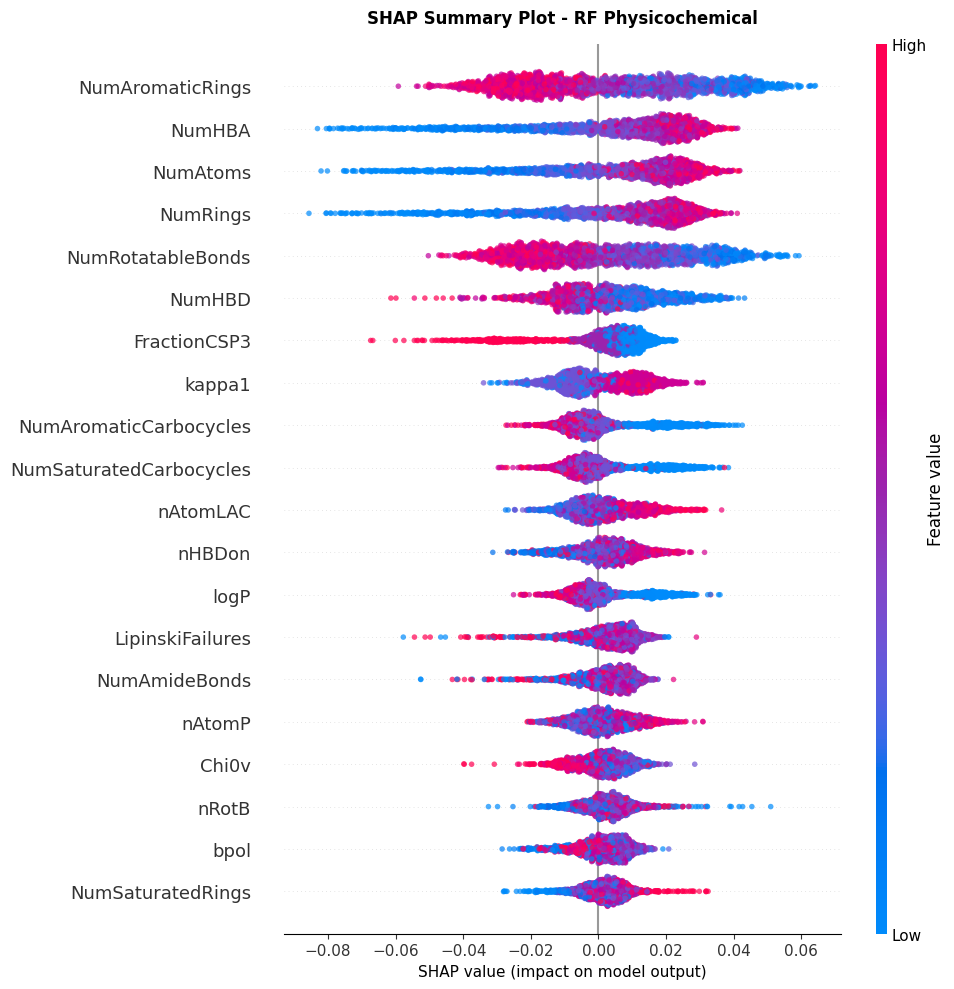

Plot tersimpan: shap_Cardiac.png


In [39]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== Nama fitur physicochemical (56 kolom) =====
feature_names = [
    "Molecular weight", "logP", "LabuteASA", "TPSA", "AMW",
    "NumLipinskiHBA", "NumLipinskiHBD", "NumRotatableBonds", "NumHBD", "NumHBA",
    "NumAmideBonds", "NumHeteroAtoms", "NumAtoms", "NumRings", "NumAromaticRings",
    "NumSaturatedRings", "NumAliphaticRings", "NumAromaticHeterocycles",
    "NumSaturatedHeterocycles", "NumAliphaticHeterocycles", "NumAromaticCarbocycles",
    "NumSaturatedCarbocycles", "NumAliphaticCarbocycles", "FractionCSP3",
    "Chi0v", "Chi1v", "Chi2v", "Chi3v", "Chi4v", "Chi1n", "Chi2n", "Chi3n", "Chi4n",
    "HallKierAlpha", "kappa1", "kappa2", "kappa3",
    "ALogP", "ALogP2", "AMR", "MLogP", "nAtomP", "naAromAtom",
    "bpol", "nHBAcc", "nHBDon", "nAtomLAC", "nAtomLC",
    "PetitjeanNumber", "nRotB", "LipinskiFailures", "TopoPSA", "VAdjMat", "XLogP", "Fsp3", "nB"
]

# ===== Buat DataFrame dengan nama kolom =====
X_phys = pd.DataFrame(x_test_rdkit_cdk, columns=feature_names)

# ===== Hitung SHAP values RF (paksa main effect only) =====
print("Menghitung SHAP values RF...")
explainer_rf = shap.TreeExplainer(rf_p)

# Gunakan model_output="probability" dan paksa main effect saja
shap_values_rf = explainer_rf(X_phys)  # versi baru SHAP API

# Cek shape
print(f"Shape shap_values_rf.values: {shap_values_rf.values.shape}")

# Kalau 3D (n_samples, n_features, n_classes) — ambil class 1
if len(shap_values_rf.values.shape) == 3:
    shap_vals = shap_values_rf.values[:, :, 1]
    print(f"Diambil class 1, shape final: {shap_vals.shape}")
else:
    shap_vals = shap_values_rf.values
    print(f"Shape final: {shap_vals.shape}")

# ===== Summary Plot (Beeswarm persis seperti gambar referensi) =====
plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_vals,
    X_phys,
    feature_names=feature_names,
    plot_type="dot",
    max_display=20,
    show=False,
    alpha=0.7,       # transparansi titik supaya tidak terlalu padat
    plot_size=None   # biarkan SHAP atur ukuran sendiri
)
plt.title("SHAP Summary Plot - RF Physicochemical", 
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel("SHAP value (impact on model output)", fontsize=11)
plt.tight_layout()
plt.savefig("shap_Cardiac.png", dpi=300, bbox_inches='tight')
plt.show()
print("Plot tersimpan: shap_Cardiac.png")

Menghitung SHAP values RF...
Shape shap_values_rf.values: (2068, 56, 2)
Diambil class 1, shape final: (2068, 56)


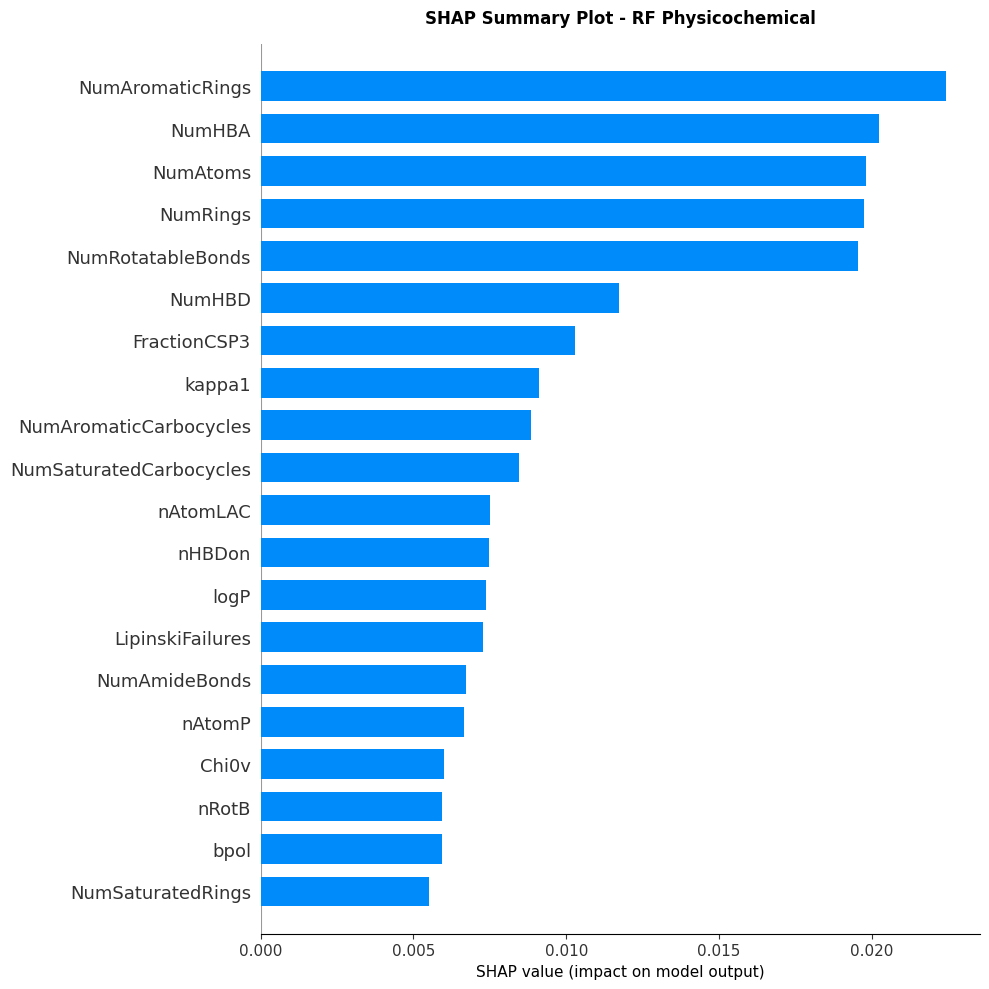

Plot tersimpan: shap_Cardiac_bar.png


In [23]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== Nama fitur physicochemical (56 kolom) =====
feature_names = [
    "Molecular weight", "logP", "LabuteASA", "TPSA", "AMW",
    "NumLipinskiHBA", "NumLipinskiHBD", "NumRotatableBonds", "NumHBD", "NumHBA",
    "NumAmideBonds", "NumHeteroAtoms", "NumAtoms", "NumRings", "NumAromaticRings",
    "NumSaturatedRings", "NumAliphaticRings", "NumAromaticHeterocycles",
    "NumSaturatedHeterocycles", "NumAliphaticHeterocycles", "NumAromaticCarbocycles",
    "NumSaturatedCarbocycles", "NumAliphaticCarbocycles", "FractionCSP3",
    "Chi0v", "Chi1v", "Chi2v", "Chi3v", "Chi4v", "Chi1n", "Chi2n", "Chi3n", "Chi4n",
    "HallKierAlpha", "kappa1", "kappa2", "kappa3",
    "ALogP", "ALogP2", "AMR", "MLogP", "nAtomP", "naAromAtom",
    "bpol", "nHBAcc", "nHBDon", "nAtomLAC", "nAtomLC",
    "PetitjeanNumber", "nRotB", "LipinskiFailures", "TopoPSA", "VAdjMat", "XLogP", "Fsp3", "nB"
]

# ===== Buat DataFrame dengan nama kolom =====
X_phys = pd.DataFrame(x_test_rdkit_cdk, columns=feature_names)

# ===== Hitung SHAP values RF (paksa main effect only) =====
print("Menghitung SHAP values RF...")
explainer_rf = shap.TreeExplainer(rf_p)

# Gunakan model_output="probability" dan paksa main effect saja
shap_values_rf = explainer_rf(X_phys)  # versi baru SHAP API

# Cek shape
print(f"Shape shap_values_rf.values: {shap_values_rf.values.shape}")

# Kalau 3D (n_samples, n_features, n_classes) — ambil class 1
if len(shap_values_rf.values.shape) == 3:
    shap_vals = shap_values_rf.values[:, :, 1]
    print(f"Diambil class 1, shape final: {shap_vals.shape}")
else:
    shap_vals = shap_values_rf.values
    print(f"Shape final: {shap_vals.shape}")

# ===== Summary Plot (Beeswarm persis seperti gambar referensi) =====
plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_vals,
    X_phys,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20,
    show=False,
    alpha=0.7,       # transparansi titik supaya tidak terlalu padat
    plot_size=None   # biarkan SHAP atur ukuran sendiri
)
plt.title("SHAP Summary Plot - RF Physicochemical", 
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel("SHAP value (impact on model output)", fontsize=11)
plt.tight_layout()
plt.savefig("shap_Cardiac_bar.png", dpi=300, bbox_inches='tight')
plt.show()
print("Plot tersimpan: shap_Cardiac_bar.png")

## XAI

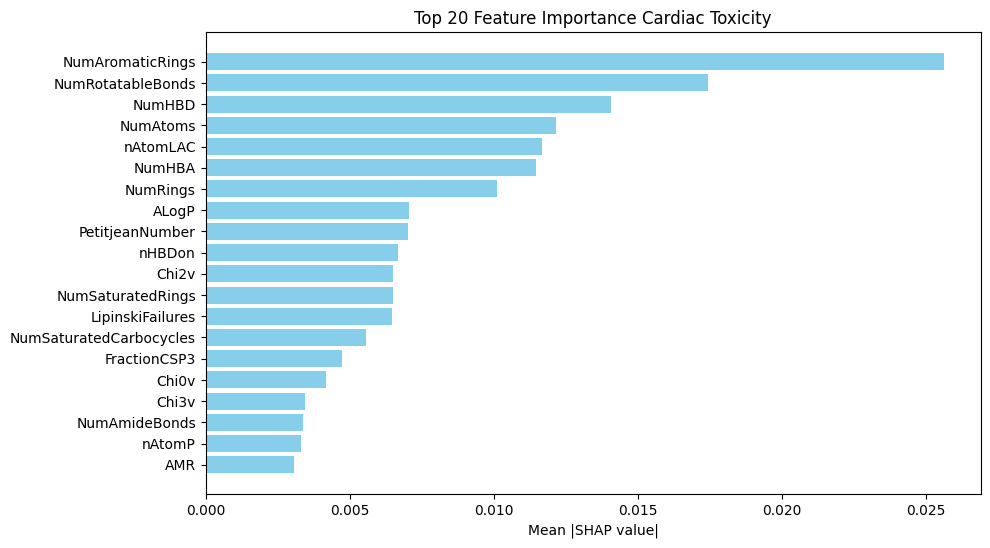

In [21]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

phys_features = [
    "Molecular weight","logP","LabuteASA","TPSA","AMW","NumLipinskiHBA","NumLipinskiHBD",
    "NumRotatableBonds","NumHBD","NumHBA","NumAmideBonds","NumHeteroAtoms","NumAtoms",
    "NumRings","NumAromaticRings","NumSaturatedRings","NumAliphaticRings","NumAromaticHeterocycles",
    "NumSaturatedHeterocycles","NumAliphaticHeterocycles","NumAromaticCarbocycles","NumSaturatedCarbocycles",
    "NumAliphaticCarbocycles","FractionCSP3","Chi0v","Chi1v","Chi2v","Chi3v","Chi4v","Chi1n","Chi2n","Chi3n",
    "Chi4n","HallKierAlpha","kappa1","kappa2","kappa3","ALogP","ALogP2","AMR","MLogP","nAtomP","naAromAtom",
    "bpol","nHBAcc","nHBDon","nAtomLAC","nAtomLC","PetitjeanNumber","nRotB","LipinskiFailures",
    "TopoPSA","VAdjMat","XLogP","Fsp3"
]

X_phys = test_df[phys_features]

explainer_phys = shap.TreeExplainer(rf_phys, feature_perturbation="interventional")
shap_values_phys = explainer_phys.shap_values(X_phys, check_additivity=False)

# Ambil SHAP values untuk kelas positif
shap_vals_class1 = shap_values_phys[:,:,1]   # (2068, 55)

# Hitung mean absolute SHAP value per fitur
importance_vals = np.abs(shap_vals_class1).mean(axis=0)  # (55,)

# Buat DataFrame ranking
importance_df = pd.DataFrame({
    "Feature": X_phys.columns,
    "Importance": importance_vals
}).sort_values(by="Importance", ascending=False)

# Ambil top 10
top10 = importance_df.head(20)

# Plot bar chart
plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Importance"], color="skyblue")
plt.gca().invert_yaxis()
plt.xlabel("Mean |SHAP value|")
plt.title("Top 20 Feature Importance Cardiac Toxicity")
plt.show()


In [41]:
# ── STEP 1: Bedah data & model ────────────────────────────────────────────────

# 1a. Cek input model langsung
X_sample = np.array(test_df['rdkit_cdk'].tolist())
print("=== Input dari rdkit_cdk ===")
print("Shape:", X_sample.shape)

# 1b. Cek kolom test_df yang match phys_features
print("\n=== test_df[phys_features] ===")
X_direct = test_df[phys_features]
print("Shape:", X_direct.shape)
print("Sample nilai:\n", X_direct.head(2))

# 1c. Cek apakah model bisa predict dari masing-masing input
print("\n=== Test predict_proba ===")
try:
    p1 = rf_phys.predict_proba(X_sample[:5])
    print("rf_phys dari rdkit_cdk OK:", p1.shape)
except Exception as e:
    print("rf_phys dari rdkit_cdk ERROR:", e)

try:
    p2 = rf_phys.predict_proba(X_direct[:5])
    print("rf_phys dari phys_features OK:", p2.shape)
except Exception as e:
    print("rf_phys dari phys_features ERROR:", e)

=== Input dari rdkit_cdk ===
Shape: (2068, 56)

=== test_df[phys_features] ===
Shape: (2068, 55)
Sample nilai:
      Molecular weight     logP   LabuteASA    TPSA      AMW  NumLipinskiHBA  \
0             582.506  3.18092  230.170792  128.80  582.506               7   
800           432.887  3.12092  177.128961  107.95  432.887               7   

     NumLipinskiHBD  NumRotatableBonds  NumHBD  NumHBA  NumAmideBonds  \
0                 3                  8       3       7              1   
800               2                  5       2       7              1   

     NumHeteroAtoms  NumAtoms  NumRings  NumAromaticRings  NumSaturatedRings  \
0                12        38         4                 3                  1   
800              10        30         4                 3                  1   

     NumAliphaticRings  NumAromaticHeterocycles  NumSaturatedHeterocycles  \
0                    1                        1                         1   
800                  1             